In [2]:
import subprocess
import sys

packages = [
    'pandas', 'numpy', 'scikit-learn', 'nltk', 'beautifulsoup4',
    'imbalanced-learn', 'matplotlib', 'seaborn', 'wordcloud', 'scipy','optuna'
]

print("Installing/verifying packages...")
for package in packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"  [OK] {package}")
    except ImportError:
        print(f"  Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("\n✓ All dependencies ready!")

Installing/verifying packages...
  [OK] pandas
  [OK] numpy
  Installing scikit-learn...
  [OK] nltk
  Installing beautifulsoup4...
  Installing imbalanced-learn...
  [OK] matplotlib
  [OK] seaborn
  [OK] wordcloud
  [OK] scipy
  Installing optuna...

✓ All dependencies ready!


In [3]:
import re, html, os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.tag import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

import nltk
for _item in ['punkt_tab', 'stopwords', 'wordnet', 'averaged_perceptron_tagger_eng']:
    try:
        nltk.data.find(
            f'tokenizers/{_item}' if 'punkt' in _item else
            f'taggers/{_item}'    if 'tagger' in _item else
            f'corpora/{_item}'
        )
    except LookupError:
        nltk.download(_item, quiet=True)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('✓ All imports and NLTK data ready!')


✓ All imports and NLTK data ready!


In [4]:
class TextCleaner:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        # Keep sentiment-bearing negations; drop recipe-domain neutral terms
        self.stopwords = (
            set(stopwords.words('english'))
            - {'no', 'not', 'very', 'never', 'nor', 'only', 'should'}
        )
        self.stopwords |= {
            'recipe', 'minutes', 'degrees', 'ingredients', 'oven',
            'cup', 'cups', 'tsp', 'tbsp', 'oz', 'lb', 'gram',
            'ml', 'serving', 'servings', 'prep'
        }

    @staticmethod
    def _get_wordnet_pos(treebank_tag):
        mapping = {'J': wordnet.ADJ, 'V': wordnet.VERB,
                   'N': wordnet.NOUN, 'R': wordnet.ADV}
        return mapping.get(treebank_tag[0], wordnet.NOUN)

    def clean_text(self, text):
        if not isinstance(text, str) or not text.strip():
            return ''

        # Step 1 — HTML decode and tag removal
        text = BeautifulSoup(text, 'html.parser').get_text()
        text = html.unescape(text)

        # Step 2 — Lowercase and keep only letters / spaces
        text = text.lower()
        text = re.sub(r'[^a-z\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()

        # Step 3 — Tokenise
        tokens = word_tokenize(text)

        # Step 4 — POS-aware lemmatisation
        pos_tags = pos_tag(tokens)
        tokens = [
            self.lemmatizer.lemmatize(tok, self._get_wordnet_pos(pos))
            for tok, pos in pos_tags
        ]

        # Step 5 — Stopword removal (min token length 2)
        tokens = [t for t in tokens if t not in self.stopwords and len(t) > 1]

        return ' '.join(tokens)


In [5]:
class MetadataEngineer:
    def __init__(self):
        self.scaler = StandardScaler()
        self.fitted = False

    def engineer_metadata(self, df, fit=False):
        df = df.copy()


        dt  = pd.to_datetime(df['created_at'], unit='s')
        month = dt.dt.month
        dow   = dt.dt.dayofweek

        df['month_sin']       = np.sin(2 * np.pi * month / 12)
        df['month_cos']       = np.cos(2 * np.pi * month / 12)
        df['day_of_week_sin'] = np.sin(2 * np.pi * dow / 7)
        df['day_of_week_cos'] = np.cos(2 * np.pi * dow / 7)


        num_cols = ['user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down']
        if fit:
            df[num_cols] = self.scaler.fit_transform(df[num_cols])
            self.fitted = True
        else:
            if not self.fitted:
                raise RuntimeError('Fit MetadataEngineer on training data first.')
            df[num_cols] = self.scaler.transform(df[num_cols])

        return df


In [6]:
class RecipeReviewPreprocessor:


    def __init__(self):
        self.text_cleaner       = TextCleaner()
        self.metadata_engineer  = MetadataEngineer()
        self.column_transformer = None   # fitted on training split only

    def load_data(self, filepath):
        df = pd.read_csv(filepath)
        print(f'Loaded shape          : {df.shape}')
        df = df[df['stars']!=0].reset_index(drop=True)
        print(f'After: {df.shape}')
        return df

    def apply_all_phases(self, df_input, is_training_set=False):

        df  = df_input.copy()
        tag = 'Training' if is_training_set else 'Val / Test'


        print(f'\n{"="*65}')
        print(f'  PHASE 1 — Text Cleaning   [{tag}]')
        print(f'{"="*65}')
        df['text_cleaned'] = df['text'].apply(self.text_cleaner.clean_text)
        print('  ✓ Done')


        print(f'\n{"="*65}')
        print(f'  PHASE 2 — Metadata Engineering   [{tag}]')
        print(f'{"="*65}')
        df = self.metadata_engineer.engineer_metadata(df, fit=is_training_set)
        print('  ✓ Done')


        print(f'\n{"="*65}')
        print(f'  PHASE 3 — Feature Fusion   [{tag}]')
        print(f'{"="*65}')

        feature_cols = [
            'text_cleaned',
            'user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down',
            'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos'
        ]
        X_pre = df[feature_cols]

        if is_training_set:
            self.column_transformer = ColumnTransformer(
                transformers=[
                    ('text', TfidfVectorizer(
                        ngram_range=(1, 3),
                        max_features=10_000,
                        min_df=2,
                        max_df=0.95,
                        lowercase=False,
                        stop_words=None
                    ), 'text_cleaned'),
                    ('num', 'passthrough',
                     ['user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down',
                      'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos'])
                ],
                remainder='drop'
            )
            X = self.column_transformer.fit_transform(X_pre)
            print(f'  ✓ Fitted + transformed.  X shape: {X.shape}')
        else:
            if self.column_transformer is None:
                raise RuntimeError('Fit the preprocessor on training data first.')
            X = self.column_transformer.transform(X_pre)
            print(f'  ✓ Transformed.  X shape: {X.shape}')

        return X


In [7]:

DATA_PATH = os.path.join(os.getcwd(), 'recipe_reviews.csv')

preprocessor = RecipeReviewPreprocessor()
df_raw = preprocessor.load_data(DATA_PATH)



print(f'\nStar rating distribution:\n{df_raw["stars"].value_counts().sort_index()}')
df_raw[['recipe_name', 'stars',  'best_score', 'text']].head()


Loaded shape          : (18182, 15)
After: (16486, 15)

Star rating distribution:
stars
1      280
2      232
3      490
4     1655
5    13829
Name: count, dtype: int64


,recipe_name,stars,best_score,text
0,Creamy White Chili,5,527,"I tweaked it a little, removed onions because ..."
1,Creamy White Chili,5,724,Bush used to have a white chili bean and it ma...
2,Creamy White Chili,5,710,I have a very complicated white chicken chili ...
3,Creamy White Chili,5,518,amazing! my boyfriend loved it so much! going ...
4,Creamy White Chili,5,833,Wow!!! This recipe is excellent as written!! ...


In [8]:
df_raw[df_raw['stars'] == 0][['stars','text']].head(10)

,stars,text


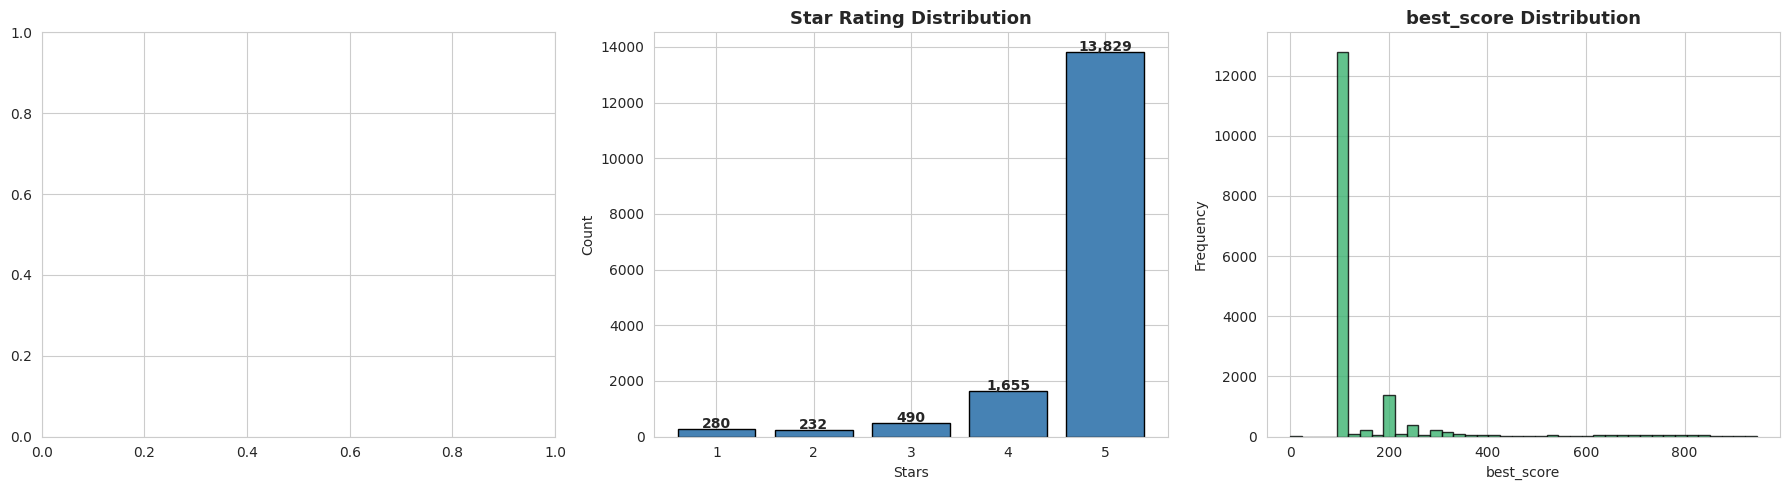


best_score stats:
count    16486.00
mean       151.07
std        137.32
min          0.00
25%        100.00
50%        100.00
75%        100.00
max        946.00
Name: best_score, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

star_counts = df_raw['stars'].value_counts().sort_index()
axes[1].bar(star_counts.index, star_counts.values,
            color='steelblue', edgecolor='black')
for i, v in enumerate(star_counts.values):
    axes[1].text(star_counts.index[i], v + 30, f'{v:,}', ha='center', fontweight='bold')
axes[1].set_title('Star Rating Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Count')


axes[2].hist(df_raw['best_score'], bins=40, color='mediumseagreen',
             edgecolor='black', alpha=0.8)
axes[2].set_title('best_score Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('best_score')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('01_eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nbest_score stats:')
print(df_raw['best_score'].describe().round(2))


Text Length Statistics:
       text_length  word_count
count      16486.0     16486.0
mean         207.4        38.5
std          174.8        32.6
min            1.0         0.0
25%           91.0        17.0
50%          165.0        30.0
75%          272.0        50.8
max         2742.0       499.0


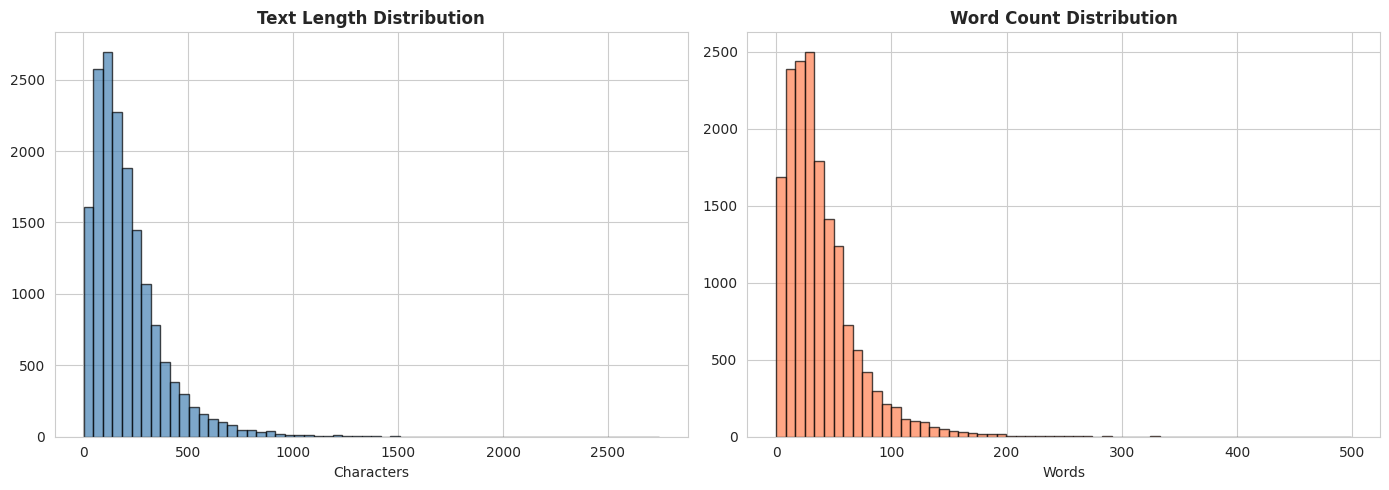

In [10]:

df_raw['text_length'] = df_raw['text'].astype(str).apply(len)
df_raw['word_count']  = df_raw['text'].astype(str).apply(lambda x: len(x.split()))

print('Text Length Statistics:')
print(df_raw[['text_length', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_raw['text_length'], bins=60, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Characters')
axes[0].set_title('Text Length Distribution', fontweight='bold')
axes[1].hist(df_raw['word_count'], bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Words')
axes[1].set_title('Word Count Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('02_text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

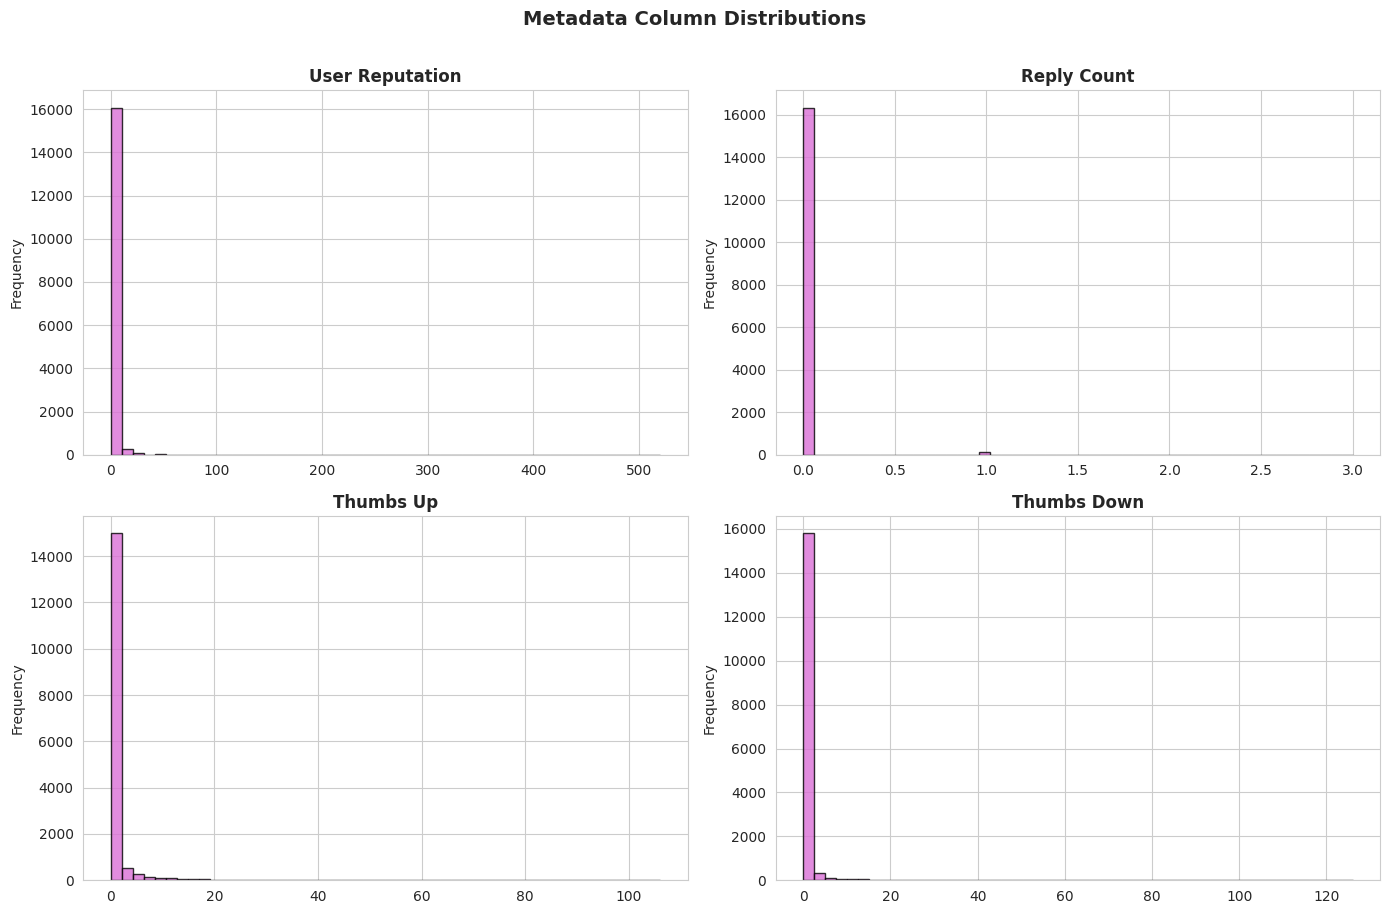

In [11]:

meta_cols = ['user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flatten(), meta_cols):
    ax.hist(df_raw[col], bins=50, color='orchid', edgecolor='black', alpha=0.8)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Frequency')
plt.suptitle('Metadata Column Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_metadata_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

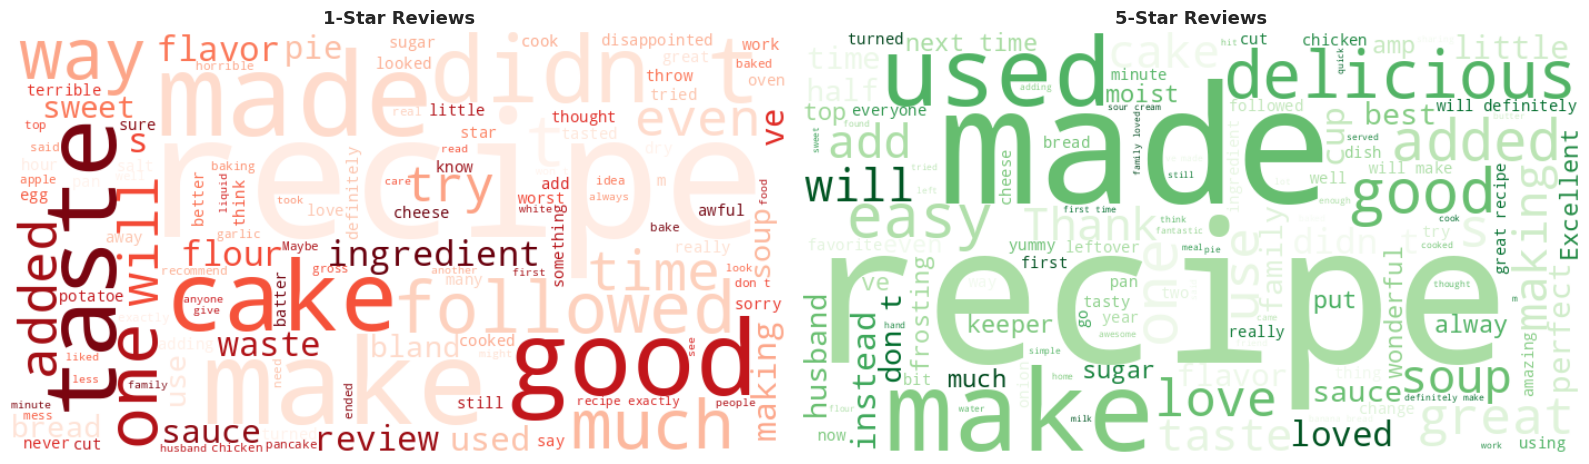

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, star, cmap in zip(axes, [1, 5], ['Reds', 'Greens']):
    combined = ' '.join(df_raw[df_raw['stars'] == star]['text'].astype(str))
    wc = WordCloud(width=700, height=380, background_color='white',
                   colormap=cmap, max_words=120).generate(combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{star}-Star Reviews', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
df_train, df_temp = train_test_split(
    df_raw, test_size=0.30, random_state=42, stratify=df_raw['stars'].astype(int)
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=42, stratify=df_temp['stars'].astype(int)
)

print(f'Train : {df_train.shape}')
print(f'Val   : {df_val.shape}')
print(f'Test  : {df_test.shape}')

y_train = df_train['stars'].values
y_val   = df_val['stars'].values
y_test  = df_test['stars'].values

print(f'\nSentiment class counts (train): {dict(pd.Series(y_train).value_counts())}')
print(f'Stratification check (val)    : {dict(pd.Series(y_val).value_counts())}')


Train : (11540, 17)
Val   : (2473, 17)
Test  : (2473, 17)

Sentiment class counts (train): {5: np.int64(9680), 4: np.int64(1159), 3: np.int64(343), 1: np.int64(196), 2: np.int64(162)}
Stratification check (val)    : {5: np.int64(2075), 4: np.int64(248), 3: np.int64(73), 1: np.int64(42), 2: np.int64(35)}


In [ ]:

X_train = preprocessor.apply_all_phases(df_train, is_training_set=True)
X_val   = preprocessor.apply_all_phases(df_val,   is_training_set=False)
X_test  = preprocessor.apply_all_phases(df_test,  is_training_set=False)

print('\n' + '='*65)
print('PREPROCESSING COMPLETE')
print('='*65)
print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')



  PHASE 1 — Text Cleaning   [Training]
  ✓ Done

  PHASE 2 — Metadata Engineering   [Training]
  ✓ Done

  PHASE 3 — Feature Fusion   [Training]
  ✓ Fitted + transformed.  X shape: (11540, 10008)

  PHASE 1 — Text Cleaning   [Val / Test]
  ✓ Done

  PHASE 2 — Metadata Engineering   [Val / Test]
  ✓ Done

  PHASE 3 — Feature Fusion   [Val / Test]
  ✓ Transformed.  X shape: (2473, 10008)

  PHASE 1 — Text Cleaning   [Val / Test]
  ✓ Done

  PHASE 2 — Metadata Engineering   [Val / Test]
  ✓ Done

  PHASE 3 — Feature Fusion   [Val / Test]
  ✓ Transformed.  X shape: (2473, 10008)

PREPROCESSING COMPLETE
X_train : (11540, 10008)
X_val   : (2473, 10008)
X_test  : (2473, 10008)


In [14]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.sparse import hstack, csr_matrix
import time
import xgboost as xgb
import optuna


In [15]:
  # IMPORTANT
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)
dtest  = xgb.DMatrix(X_test, label=y_test)

NameError: name 'X_train' is not defined

In [ ]:
def objective(trial):

    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "seed": 42,
        "verbosity": 0,
    }


    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain, "train"), (dval, "val")],
        early_stopping_rounds=30,
        verbose_eval=False,

    )


    return model.best_score

In [ ]:

t0 = time.time()
print("Starting Optuna hyperparameter tuning...")

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print(f"\nOptimization finished in {time.time() - t0:.1f}s")
print(f"Best trial validation RMSE: {study.best_value:.4f}")
print("Best hyperparameters:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

[I 2026-04-09 12:44:08,215] A new study created in memory with name: no-name-ce264fb9-464f-4c43-b2e6-bd796391e424


Starting Optuna hyperparameter tuning...


[I 2026-04-09 12:44:48,151] Trial 0 finished with value: 0.5727447215985138 and parameters: {'learning_rate': 0.06772557270703723, 'max_depth': 3, 'subsample': 0.6654106118069495, 'colsample_bytree': 0.9065831800550412, 'min_child_weight': 8, 'gamma': 0.000545695835189322, 'reg_alpha': 0.019770712337833913, 'reg_lambda': 2.807420808549373e-06}. Best is trial 0 with value: 0.5727447215985138.
[I 2026-04-09 12:45:05,824] Trial 1 finished with value: 0.5740081394959082 and parameters: {'learning_rate': 0.135749465795166, 'max_depth': 3, 'subsample': 0.7911587085072307, 'colsample_bytree': 0.9772501551784285, 'min_child_weight': 9, 'gamma': 0.4179714917152184, 'reg_alpha': 4.040181290615215e-06, 'reg_lambda': 0.0009483951267041721}. Best is trial 0 with value: 0.5727447215985138.
[I 2026-04-09 12:47:14,134] Trial 2 finished with value: 0.5640764083932063 and parameters: {'learning_rate': 0.01725189340085468, 'max_depth': 6, 'subsample': 0.5808839219482833, 'colsample_bytree': 0.96864026809


Optimization finished in 4509.8s
Best trial validation RMSE: 0.5433
Best hyperparameters:
    learning_rate: 0.07881806726861924
    max_depth: 8
    subsample: 0.8613990774512911
    colsample_bytree: 0.7796150379304092
    min_child_weight: 1
    gamma: 0.0038231501639743783
    reg_alpha: 5.7113039770936584
    reg_lambda: 4.552244099291356


In [ ]:
best_params = {
    "objective": "reg:squarederror",
    "eval_metric": ["rmse", "mae"],
    "learning_rate": 0.07881806726861924,
    "max_depth": 8,
    "subsample":  0.8613990774512911,
    "colsample_bytree": 0.7796150379304092,
    "min_child_weight": 1,
    "gamma": 0.0038231501639743783,
    "reg_alpha":  5.7113039770936584,
    "reg_lambda": 4.552244099291356,
    "seed": 42,
    "verbosity": 0
}

In [ ]:
t_start = time.time()
final_model = xgb.train(
    best_params,
    dtrain,
    num_boost_round=2000,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=100,
    verbose_eval=100
)


preds = final_model.predict(dtest)
actuals = dtest.get_label()


within_tolerance = np.abs(preds - actuals) <= 0.5
rounding_acc = np.mean(within_tolerance) * 100

print("-" * 30)
print(f"Final Model Results:")
print(f"Best Iteration      : {final_model.best_iteration}")
print(f"Final Val RMSE      : {final_model.best_score:.4f}")
print(f"Rounding Accuracy   : {rounding_acc:.2f}% (within ±0.5)")
print(f"Total Training Time : {time.time() - t_start:.1f}s")

[0]	train-rmse:0.72243	train-mae:0.44325	val-rmse:0.72584	val-mae:0.44488
[100]	train-rmse:0.46072	train-mae:0.25998	val-rmse:0.55410	val-mae:0.31365
[200]	train-rmse:0.41425	train-mae:0.23518	val-rmse:0.54570	val-mae:0.31394
[227]	train-rmse:0.40533	train-mae:0.23019	val-rmse:0.54452	val-mae:0.31449
------------------------------
Final Model Results:
Best Iteration      : 127
Final Val RMSE      : 0.3118
Rounding Accuracy   : 79.42% (within ±0.5)
Total Training Time : 93.4s


In [ ]:


preds = final_model.predict(dtest)
actuals = y_test

acc_05 = np.mean(np.abs(preds - actuals) <= 0.5) * 100

acc_10 = np.mean(np.abs(preds - actuals) <= 1.0) * 100

print("-" * 35)
print(f"FINAL MODEL PERFORMANCE (on dtest):")
print(f"Best Iteration      : {final_model.best_iteration}")
print(f"Final Val RMSE      : {final_model.best_score:.4f}")
print(f"Accuracy (±0.5)     : {acc_05:.2f}%")
print(f"Accuracy (±1.0)     : {acc_10:.2f}%")
print(f"Total Training Time : {time.time() - t_start:.1f}s")
print("-" * 35)

-----------------------------------
FINAL MODEL PERFORMANCE (on dtest):
Best Iteration      : 127
Final Val RMSE      : 0.3118
Accuracy (±0.5)     : 79.42%
Accuracy (±1.0)     : 93.57%
Total Training Time : 175.0s
-----------------------------------


In [ ]:
rounded_preds = np.round(np.clip(preds, 1, 5))


one_star_mask = (y_test == 1)
if one_star_mask.sum() > 0:
    one_star_acc = np.mean(rounded_preds[one_star_mask] == y_test[one_star_mask])
    print(f"Accuracy for 1-star ratings: {one_star_acc * 100:.2f}%")

Accuracy for 1-star ratings: 2.38%


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pickle
import os


drive_path = '/content/drive/MyDrive/model_artifacts'


os.makedirs(drive_path, exist_ok=True)


final_model.save_model(os.path.join(drive_path, 'xgboost_final_model.json'))

In [ ]:
import pickle
import os


drive_path = '/content/drive/MyDrive/model_artifacts'
os.makedirs(drive_path, exist_ok=True)


artifacts = {
    'column_transformer': preprocessor.column_transformer,
    'metadata_engineer': preprocessor.metadata_engineer
}

artifacts_path = os.path.join(drive_path, 'preprocessing_artifacts.pkl')
with open(artifacts_path, 'wb') as f:
    pickle.dump(artifacts, f)

print(f'✓ Preprocessing artifacts saved to: {artifacts_path}')

✓ Preprocessing artifacts saved to: /content/drive/MyDrive/model_artifacts/preprocessing_artifacts.pkl


## Previous work

In [19]:
import xgboost as xgb
import pickle
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score


drive_path = '/content/drive/MyDrive/model_artifacts'
model_path = os.path.join(drive_path, 'xgboost_final_model.json')
artifacts_path = os.path.join(drive_path, 'preprocessing_artifacts.pkl')


loaded_model = xgb.Booster()
loaded_model.load_model(model_path)
print("✓ Model loaded from Drive")


with open(artifacts_path, 'rb') as f:
    loaded_artifacts = pickle.load(f)

loaded_ct = loaded_artifacts['column_transformer']
loaded_me = loaded_artifacts['metadata_engineer']
print("✓ Preprocessing artifacts loaded from Drive")


df_test_reloaded = df_test.copy()


df_test_reloaded['text_cleaned'] = df_test_reloaded['text'].apply(preprocessor.text_cleaner.clean_text)

df_test_reloaded = loaded_me.engineer_metadata(df_test_reloaded, fit=False)

feature_cols = [
    'text_cleaned',
    'user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down',
    'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos'
]
X_test_reloaded = loaded_ct.transform(df_test_reloaded[feature_cols])

dtest_reloaded = xgb.DMatrix(X_test_reloaded)
reloaded_preds = loaded_model.predict(dtest_reloaded)

reloaded_acc_05 = np.mean(np.abs(reloaded_preds - y_test) <= 0.5) * 100
reloaded_acc_10 = np.mean(np.abs(reloaded_preds - y_test) <= 1.0) * 100

mse = mean_squared_error(y_test, reloaded_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, reloaded_preds)

print("\n" + "="*40)
print("RELOADED MODEL PERFORMANCE:")
print(f"Accuracy (\u00b10.5): {reloaded_acc_05:.2f}%")
print(f"Accuracy (\u00b11.0): {reloaded_acc_10:.2f}%")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print("="*40)

✓ Model loaded from Drive
✓ Preprocessing artifacts loaded from Drive

RELOADED MODEL PERFORMANCE:
Accuracy (±0.5): 79.42%
Accuracy (±1.0): 93.57%
Mean Squared Error (MSE): 0.3169
Root Mean Squared Error (RMSE): 0.5629
R-squared (R2): 0.4196


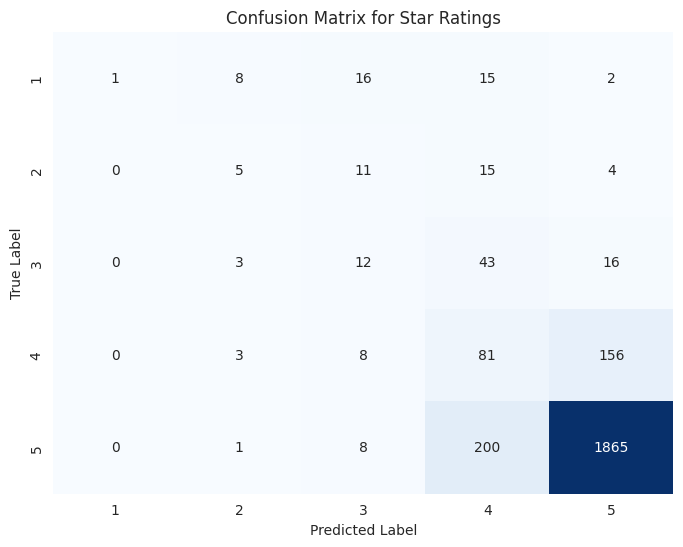

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Round predictions to nearest integer and clip to the 1-5 star range
rounded_reloaded_preds = np.round(np.clip(reloaded_preds, 1, 5)).astype(int)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, rounded_reloaded_preds)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.arange(1, 6), yticklabels=np.arange(1, 6))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Star Ratings')
plt.show()